## Regression Modeling using PySpark ML Pipeline

### References:
- https://spark.apache.org/docs/latest/api/python/reference/pyspark.ml.html
- https://kb.databricks.com/machine-learning/extract-feature-info.html

In [1]:
import os

import math
import matplotlib.pyplot as plt
import numpy as np
import pyspark.sql.functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import MinMaxScaler, VectorAssembler

import geofunctions as S

In [2]:
schema = ",".join(
    [
        "id string",
        "vendor_id string",
        "pickup_datetime timestamp",
        "dropoff_datetime timestamp",
        "passenger_count integer",
        "pickup_longitude double",
        "pickup_latitude double",
        "dropoff_longitude double",
        "dropoff_latitude double",
        "store_and_fwd_flag string",
        "trip_duration integer",  # seconds
    ]
)

In [3]:
xmin, xmax, ymin, ymax = [
    -74.04226680414989,
    -73.5061146385722,
    40.6059735081628,
    40.91340235669589,
]

where = " and ".join(
    [
        f"p_lon between {xmin}D and {xmax}D",
        f"p_lat between {ymin}D and {ymax}D",
        f"d_lon between {xmin}D and {xmax}D",
        f"d_lat between {ymin}D and {ymax}D",
        "label between 60 and 5400",
        "haversine between 10D and 32000D"
    ]
)

to_pi = 2.0 * math.pi / 23.0

In [4]:
csv_path = os.path.expanduser("~/data/nyc-taxi-trip-duration/train.csv")


df = (
    spark.read.csv(csv_path, schema=schema, sep=",", mode="DROPMALFORMED")
    .drop("id", "vendor_id", "passenger_count", "store_and_fwd_flag")
    .withColumnRenamed("pickup_datetime", "p_date")
    .withColumnRenamed("pickup_longitude", "p_lon")
    .withColumnRenamed("pickup_latitude", "p_lat")
    .withColumnRenamed("dropoff_datetime", "d_date")
    .withColumnRenamed("dropoff_longitude", "d_lon")
    .withColumnRenamed("dropoff_latitude", "d_lat")
    .withColumnRenamed("trip_duration", "label")
    .withColumn("haversine", S.st_haversine("p_lat", "p_lon", "d_lat", "d_lon"))
    .where(where)
    .withColumn("pi", F.hour("p_date") * to_pi)
    .withColumn("hh_cos", F.cos("pi"))
    .withColumn("hh_sin", F.sin("pi"))
    # .withColumn("haversine", F.log("haversine"))
    # .withColumn("label", F.log("label"))
    .drop("pi")
)

In [5]:
train, valid = df.randomSplit([0.7, 0.3], seed=42)
train = train.cache()

In [6]:
from pyspark.ml.regression import RandomForestRegressor

reg = RandomForestRegressor(numTrees=64, maxDepth=5, maxBins=32)

In [7]:
assembler = VectorAssembler(
    inputCols=["p_lon", "p_lat", "d_lon", "d_lat", "haversine", "hh_cos", "hh_sin"],
    # inputCols=["p_lon", "p_lat", "d_lon", "d_lat", "haversine"],
    outputCol="out",
)

scaler = MinMaxScaler(inputCol="out", outputCol="features")

pipeline = Pipeline(stages=[assembler, scaler, reg])

In [8]:
model = pipeline.fit(train)

In [9]:
reg_model = model.stages[-1]

In [10]:
features = np.array(assembler.getInputCols())
importances = reg_model.featureImportances.toArray()
indices = np.argsort(importances)

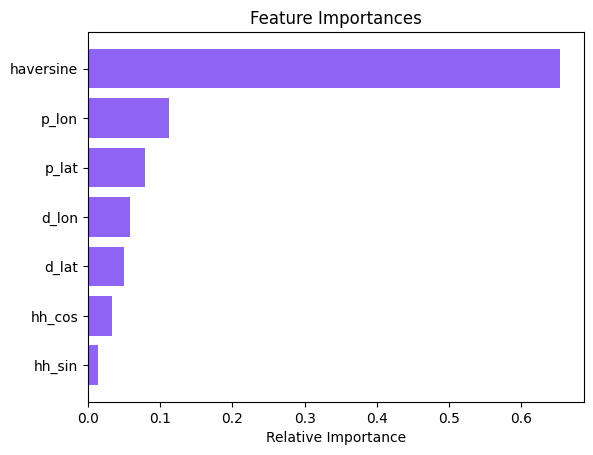

In [11]:
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="#8f63f4", align="center")
plt.yticks(range(len(indices)), features[indices])
plt.xlabel("Relative Importance")
plt.show()

In [12]:
# for feature, importance in zip(assembler.getInputCols(), reg_model.featureImportances):
#     print(f"{feature}: {importance:.4f}")

In [13]:
predictions = model.transform(valid)

In [14]:
predictions.select("label", "prediction").show()

+-----+------------------+
|label|        prediction|
+-----+------------------+
| 1829|  1195.42320267507|
| 1149| 986.6813363877029|
|  675|1181.1703729274686|
|  484| 679.2024406730407|
|  635|1121.1544835110547|
|  823| 722.8378428292854|
|  668| 573.6207563255227|
|  984| 964.7111431581599|
|  794| 945.6145859959928|
| 1070| 559.4266035675778|
|  512| 746.7228969975647|
|  637| 576.1346741249314|
|  837|1249.3992505377616|
| 1335|1408.5048618112883|
| 1589|1300.3286286950388|
|  711|1162.0324433274895|
|  794| 961.0198024350173|
| 1374| 721.5094203608448|
| 1399| 1135.000272571854|
|  270| 643.4273611277969|
+-----+------------------+
only showing top 20 rows



In [15]:
(
    predictions
    .select((F.col("label") - F.col("prediction")).alias("dd"))
    .select((F.col("dd") * F.col("dd")).alias("dd"))
    .agg(F.avg("dd").alias("mse"))
    # .select((F.sqrt("dd") / 60.0).alias("err in min"))
    .show()
)

[Stage 19:===========================>                           (10 + 10) / 20]

+------------------+
|               mse|
+------------------+
|158178.72356563437|
+------------------+



In [16]:
from pyspark.ml.evaluation import RegressionEvaluator

evaluator = RegressionEvaluator(labelCol="label", predictionCol="prediction")

In [17]:
mse = evaluator.evaluate(predictions, {evaluator.metricName: "mse"})
r2 = evaluator.evaluate(predictions, {evaluator.metricName: "r2"})

mse, r2

(158178.7235656344, 0.6077653135893706)